# Notebook 01 — Data Exploration and Preprocessing

**MALDI-MSI Analysis of Mouse Urinary Bladder**  
Author: Reza Rajaee

---

## What this notebook covers

1. What is MALDI-MSI data and how it is structured
2. Loading and exploring the dataset
3. TIC map and mean spectrum
4. Comparing individual pixel spectra
5. Complete preprocessing pipeline with step-by-step visualisation
6. Most abundant peaks per lipid class
7. PCA before and after preprocessing
8. t-SNE before and after preprocessing

---

## Dataset

**Mouse urinary bladder** — Römpp et al. (2010) *Angew. Chem. Int. Ed.* 49:3834  
**Source:** PRIDE accession PXD001283  
**Instrument:** AP-SMALDI LTQ Orbitrap, 10 µm spatial resolution  
**Format:** Centroided imzML — peaks pre-detected by instrument, baseline removed

The bladder tissue has three anatomical layers with distinct lipid compositions:
- **Urothelium** — inner epithelial lining
- **Muscle layer** — smooth muscle tissue
- **Connective tissue** — outer supportive layer

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from pathlib import Path
import sys, os

os.chdir("/workspaces/maldi-msi-analysis")
sys.path.insert(0, "/workspaces/maldi-msi-analysis")

os.makedirs("results/figures", exist_ok=True)
os.makedirs("results/tables",  exist_ok=True)

plt.rcParams.update({"figure.dpi": 130, "font.size": 10,
                      "axes.spines.top": False,
                      "axes.spines.right": False})

# Import utility functions — assign_lipid_class lives in src.visualisation
# and is used in both ion images (Section 6) and top peaks (Section 7)
from src.visualisation import assign_lipid_class

print("Setup complete. Working directory:", os.getcwd())

Setup complete. Working directory: /workspaces/maldi-msi-analysis


## 1. What is MALDI-MSI Data?

MALDI-MSI acquires a full mass spectrum at every pixel of a tissue section,
producing a **3D data cube**:

```
pixels (x) × pixels (y) × m/z values
```

**How it works:**
1. Tissue section placed on conductive slide
2. Chemical matrix sprayed onto tissue
3. UV laser scans tissue pixel by pixel
4. At each pixel: laser ionizes molecules
5. Detector records molecules by mass-to-charge ratio (m/z) and abundance

**Key concepts:**
- **m/z value**: identifies a molecule by its mass. Each lipid species has a characteristic m/z.
- **Ion image**: plot of one m/z intensity across all pixels — shows where that molecule is located
- **Mass spectrum**: all m/z values and their intensities at one pixel

**This dataset:** The data is already **centroided** — peaks are pre-detected by the
instrument and the baseline is removed. We receive discrete peak lists per pixel,
not continuous spectra.

Reference: Römpp et al. (2010) *Angew. Chem. Int. Ed.* 49:3834

## 2. Load the Dataset

In [2]:
from src.load import load_imzml, reconstruct_image

data = load_imzml(
    filepath = "data/mouse_bladder.imzML",
    mz_min   = 400,
    mz_max   = 1000,
    verbose  = True
)

spectra     = data["spectra"]
mz_values   = data["mz_values"]
coordinates = data["coordinates"]

x = coordinates["x"].values.astype(int) - coordinates["x"].min()
y = coordinates["y"].values.astype(int) - coordinates["y"].min()

print(f"\nDataset summary:")
print(f"  Pixels:        {data['n_pixels']}")
print(f"  m/z values:    {data['n_mz']}")
print(f"  m/z range:     {mz_values.min():.2f} — {mz_values.max():.2f} Da")
print(f"  Image size:    {x.max()+1} x {y.max()+1} pixels")

Loading: data/mouse_bladder.imzML
  Pixels: 34840
  m/z range: 400–1000 Da
  m/z values after range filter: 1129
  Loaded 5000/34840 pixels...
  Loaded 10000/34840 pixels...
  Loaded 15000/34840 pixels...
  Loaded 20000/34840 pixels...
  Loaded 25000/34840 pixels...
  Loaded 30000/34840 pixels...
  Done. Matrix shape: (34840, 1129)
  Memory: 157.3 MB

Dataset summary:
  Pixels:        34840
  m/z values:    1129
  m/z range:     404.09 — 988.23 Da
  Image size:    260 x 134 pixels


## 3. TIC Map and Mean Spectrum

The **TIC (Total Ion Current) map** shows the SUM of all peak intensities
at each pixel. It gives a spatial overview of where the tissue is located
and where total molecular signal is strongest.

**Important:** This is NOT a mean ion image. It sums ALL m/z values per pixel
into one value. Bright areas = more total molecular signal at that pixel.

The **mean spectrum** averages intensities across all pixels at each m/z value.
Since the data is centroided, it appears as discrete vertical lines — one per
detected peak. This is expected, not an error.

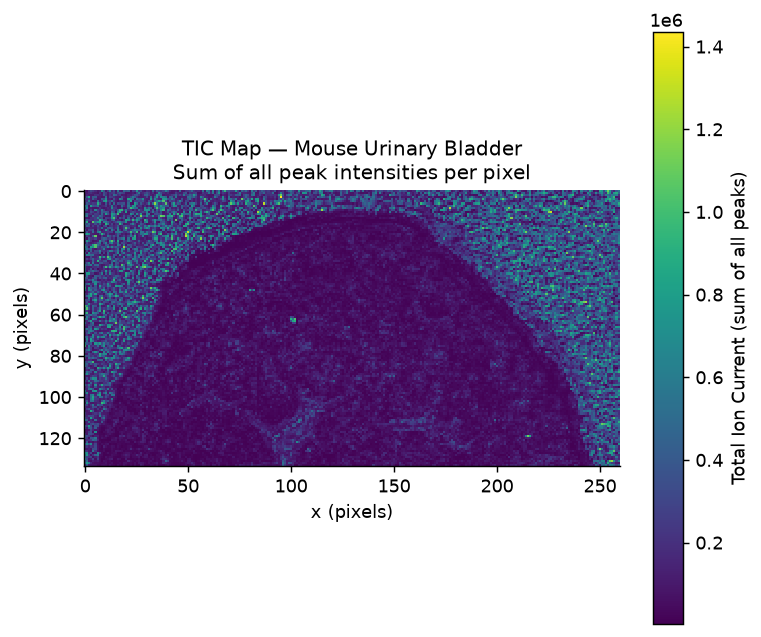

Figure saved.


In [3]:
tic     = spectra.sum(axis=1)
tic_map = reconstruct_image(tic, coordinates)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(tic_map, cmap="viridis", interpolation="nearest", aspect="equal")
plt.colorbar(im, ax=ax, label="Total Ion Current (sum of all peaks)")
ax.set_title("TIC Map — Mouse Urinary Bladder\n"
             "Sum of all peak intensities per pixel")
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
plt.tight_layout()
plt.savefig("results/figures/01_tic_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

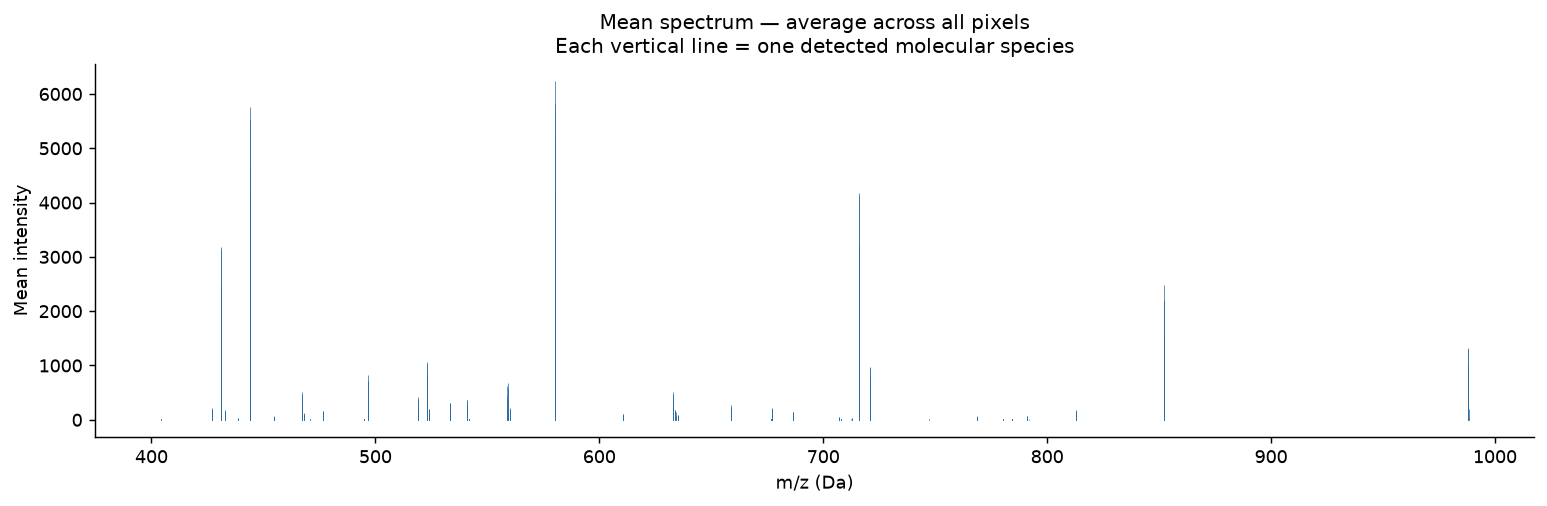

Figure saved.
Total peaks in mean spectrum: 1129


In [4]:
mean_spectrum = spectra.mean(axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.vlines(mz_values, ymin=0, ymax=mean_spectrum,
          linewidth=0.5, color="#2d6a9f", alpha=0.8)
ax.set_xlabel("m/z (Da)")
ax.set_ylabel("Mean intensity")
ax.set_title("Mean spectrum — average across all pixels\n"
             "Each vertical line = one detected molecular species")
plt.tight_layout()
plt.savefig("results/figures/01_mean_spectrum.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")
print(f"Total peaks in mean spectrum: {(mean_spectrum > 0).sum()}")

## 4. Comparing Individual Pixel Spectra

Each pixel has its own spectrum. Pixels from different tissue regions
have different spectral profiles. We compare one pixel from the tissue
centre vs one from the periphery to demonstrate molecular heterogeneity
and motivate why preprocessing is needed to make pixels comparable.

The zoomed view (700–800 Da) focuses on the phospholipid region where
the differences between tissue layers are most pronounced.

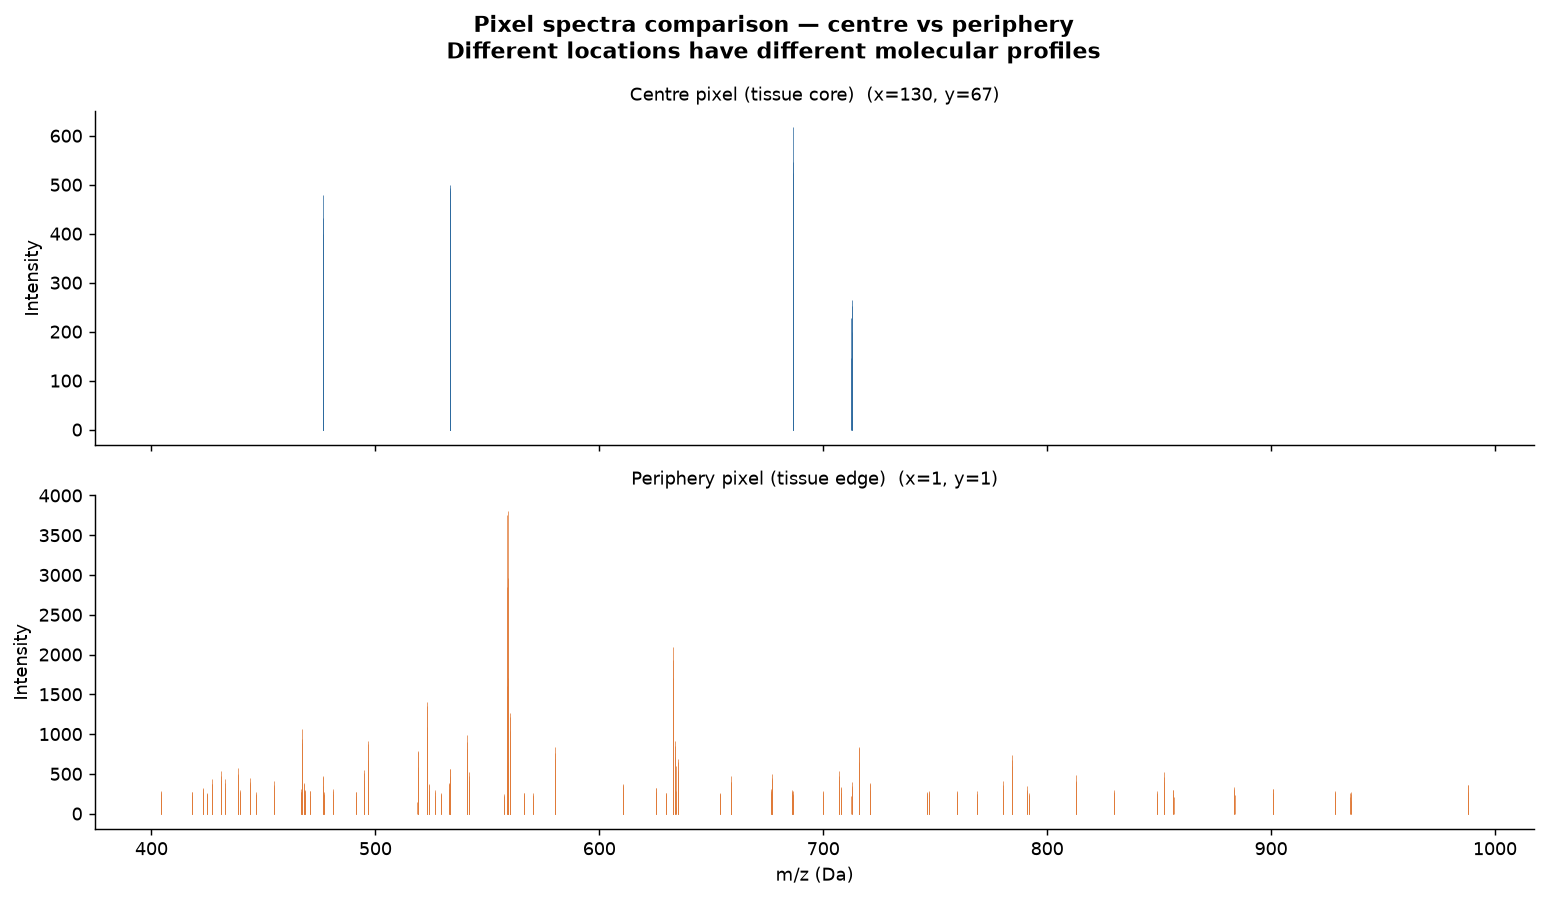

In [5]:
cx = coordinates["x"].mean()
cy = coordinates["y"].mean()
dist = np.sqrt((coordinates["x"] - cx)**2 + (coordinates["y"] - cy)**2)

centre_idx = dist.idxmin()
periph_idx = dist.idxmax()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for ax, idx, label, colour in zip(
    axes,
    [centre_idx, periph_idx],
    ["Centre pixel (tissue core)", "Periphery pixel (tissue edge)"],
    ["#2d6a9f", "#e07b39"]
):
    ax.vlines(mz_values, ymin=0, ymax=spectra[idx],
              linewidth=0.5, color=colour, alpha=0.8)
    ax.set_ylabel("Intensity")
    ax.set_title(f"{label}  "
                 f"(x={coordinates['x'][idx]}, y={coordinates['y'][idx]})",
                 fontsize=10)

axes[-1].set_xlabel("m/z (Da)")
fig.suptitle("Pixel spectra comparison — centre vs periphery\n"
             "Different locations have different molecular profiles",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/01_pixel_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

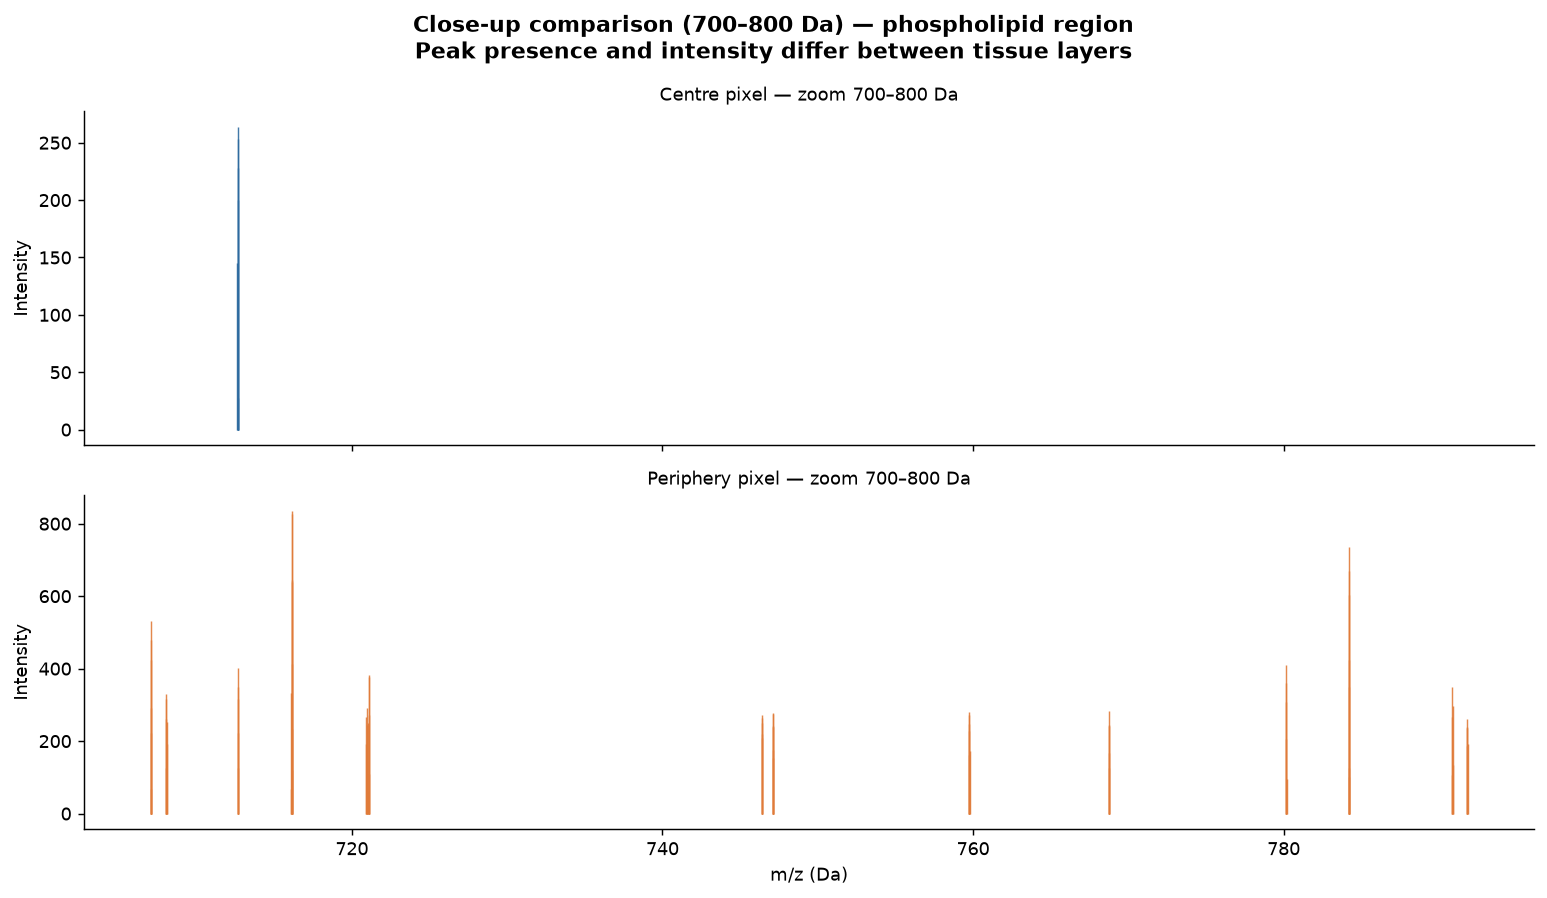

Figures saved.


In [6]:
# Close-up comparison — phospholipid region 700-800 Da
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
zoom_mask = (mz_values >= 700) & (mz_values <= 800)

for ax, idx, label, colour in zip(
    axes,
    [centre_idx, periph_idx],
    ["Centre pixel — zoom 700–800 Da", "Periphery pixel — zoom 700–800 Da"],
    ["#2d6a9f", "#e07b39"]
):
    ax.vlines(mz_values[zoom_mask], ymin=0, ymax=spectra[idx][zoom_mask],
              linewidth=0.8, color=colour, alpha=0.9)
    ax.set_ylabel("Intensity")
    ax.set_title(label, fontsize=10)

axes[-1].set_xlabel("m/z (Da)")
fig.suptitle("Close-up comparison (700–800 Da) — phospholipid region\n"
             "Peak presence and intensity differ between tissue layers",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/01_pixel_comparison_zoom.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figures saved.")

## 5. Preprocessing Pipeline

The data is already centroided — peaks are pre-detected and baseline removed.
We apply four preprocessing steps to create a consistent, comparable feature
matrix across all pixels.

---

### Step 1 — Rebinning at 10 ppm

Even in centroided data, the same molecule may be detected at slightly different
m/z positions in different pixels due to instrument calibration variation.
Rebinning groups m/z values within 10 ppm tolerance into common bins,
creating a consistent m/z axis across all pixels. 10 ppm matches the
mass accuracy of the Orbitrap instrument used for this dataset.

**Reference:** Bemis, Föll et al. (2023) *Nature Methods* 20:1883

---

### Step 2 — TIC Normalisation

Divides each pixel spectrum by its total intensity (TIC).
Corrects for pixel-to-pixel variation in total signal caused by
differences in tissue thickness, matrix crystal size, or laser absorption.
After normalisation, each spectrum sums to 1.0, making intensities
comparable across pixels.

**Reference:** Deininger et al. (2011) *Anal. Chem.* 84:1277

---

### Step 3 — Frequency Filtering at 2.5%

Keeps only peaks present in at least 2.5% of all pixels.
Removes noise peaks that appear in very few pixels and are
unlikely to represent real molecular signals.
The remaining peaks become the **reference peak list**.

**Reference:** Bemis, Föll et al. (2023) *Nature Methods* 20:1883

---

### Step 4 — Rebinning to Reference Peaks

For each reference peak, integrates (sums) all intensities within
10 ppm from each pixel. Produces the final feature matrix:
pixels × reference peaks.

**Reference:** Bemis, Föll et al. (2023) *Nature Methods* 20:1883

In [7]:
from src.preprocessing import (
    rebin_at_resolution, normalise_tic,
    filter_peaks_frequency, rebin_to_reference,
    run_preprocessing
)

preprocessed = run_preprocessing(
    spectra       = spectra,
    mz_values     = mz_values,
    tolerance_ppm = 10.0,
    min_freq      = 0.025,
    verbose       = True
)

spectra_binned = preprocessed["spectra_binned"]
spectra_norm   = preprocessed["spectra_norm"]
spectra_pp     = preprocessed["spectra_preprocessed"]
ref_mz         = preprocessed["reference_mz"]
bin_mz         = preprocessed["bin_mz"]
frequency      = preprocessed["frequency"]

print(f"\nPreprocessing summary:")
print(f"  Original m/z values:   {spectra.shape[1]}")
print(f"  After step 1 (rebin):  {len(bin_mz)}")
print(f"  After step 3 (filter): {len(ref_mz)}")
print(f"  Final matrix:          {spectra_pp.shape}")

── Preprocessing pipeline ───────────────────────────
  Input: 34840 pixels x 1129 m/z values

  [1] Rebinning at 10.0 ppm
      Groups nearby m/z values into common bins.
      Ensures same m/z axis across all pixels.
      m/z bins after rebinning: 381

  [2] TIC normalisation
      Divides each spectrum by its total intensity.
      Corrects for pixel-level technical variation.

  [3] Frequency filtering (threshold: 2.5%)
      Keeps peaks present in >= 2.5% of pixels.
      Removes noise peaks that appear in very few pixels.
      Peaks retained: 153 / 381

  [4] Rebinning to reference peaks (10.0 ppm)
      Assigns each pixel intensity to nearest reference peak.

  Done. Final matrix: 34840 x 153

Preprocessing summary:
  Original m/z values:   1129
  After step 1 (rebin):  381
  After step 3 (filter): 153
  Final matrix:          (34840, 153)


### Step 1 visualisation — 10 ppm rebinning

For Orbitrap centroided data the rebinning effect is subtle — the instrument
already performs peak detection at high mass accuracy. We show two things:
the distribution of pairwise m/z gaps (to justify why 10 ppm is the right
threshold), and the total reduction in feature count after merging.

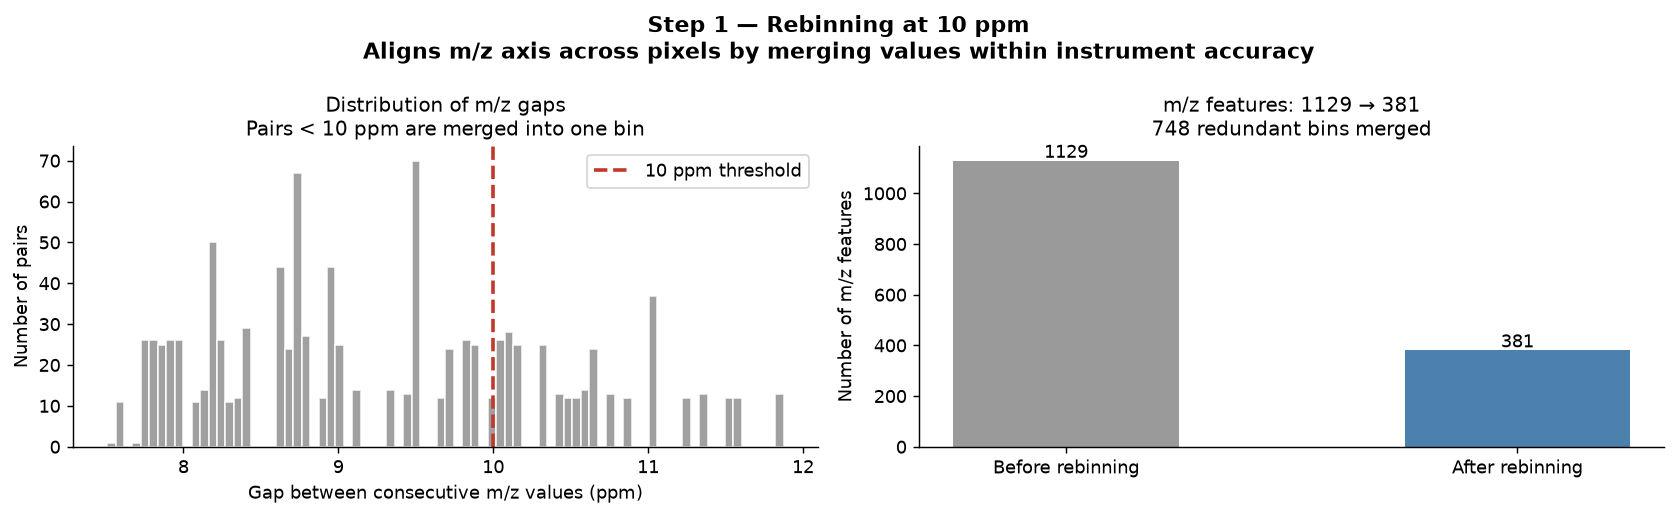

Figure saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left — distribution of pairwise m/z gaps in ppm
# Pairs below the threshold are merged into one bin
gaps_ppm = np.diff(mz_values) / mz_values[:-1] * 1e6
axes[0].hist(gaps_ppm[gaps_ppm < 50], bins=80,
             color="#888888", alpha=0.8, edgecolor="white")
axes[0].axvline(x=10, color="#c0392b", linestyle="--",
                linewidth=2, label="10 ppm threshold")
axes[0].set_xlabel("Gap between consecutive m/z values (ppm)")
axes[0].set_ylabel("Number of pairs")
axes[0].set_title("Distribution of m/z gaps\n"
                  "Pairs < 10 ppm are merged into one bin")
axes[0].legend()

# Right — feature count before vs after
axes[1].bar(["Before rebinning", "After rebinning"],
            [len(mz_values), len(bin_mz)],
            color=["#888888", "#2d6a9f"], alpha=0.85, width=0.5)
axes[1].set_ylabel("Number of m/z features")
axes[1].set_title(f"m/z features: {len(mz_values)} → {len(bin_mz)}\n"
                  f"{len(mz_values) - len(bin_mz)} redundant bins merged")
for i, v in enumerate([len(mz_values), len(bin_mz)]):
    axes[1].text(i, v + max(len(mz_values), len(bin_mz)) * 0.01,
                 str(v), ha="center", fontsize=10)

fig.suptitle("Step 1 — Rebinning at 10 ppm\n"
             "Aligns m/z axis across pixels by merging values within instrument accuracy",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/01_step1_rebinning.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

### Step 2 visualisation — TIC normalisation

TIC normalisation corrects **pixel-to-pixel variation in total signal**.
The key diagnostic is the distribution of TIC per pixel before and after:
before normalisation, pixels have variable total signal (caused by tissue
thickness, matrix crystal size, laser absorption); after, every pixel
sums to exactly 1.0, making intensities directly comparable.

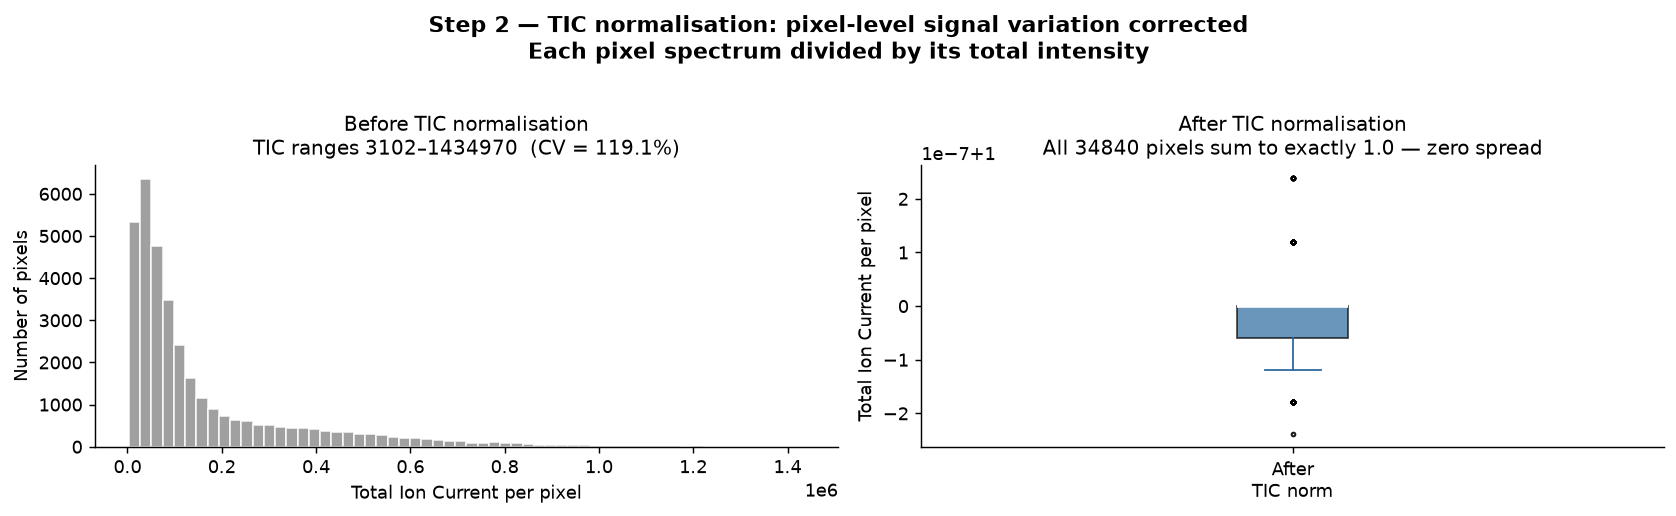

Figure saved.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left — TIC per pixel before normalisation
# Shows the variation we are correcting for
tic_per_pixel = spectra_binned.sum(axis=1)
axes[0].hist(tic_per_pixel, bins=60, color="#888888", alpha=0.8, edgecolor="white")
axes[0].set_xlabel("Total Ion Current per pixel")
axes[0].set_ylabel("Number of pixels")
axes[0].set_title(f"Before TIC normalisation\n"
                  f"TIC ranges {tic_per_pixel.min():.0f}–{tic_per_pixel.max():.0f}  "
                  f"(CV = {tic_per_pixel.std()/tic_per_pixel.mean()*100:.1f}%)")

# Right — after normalisation every pixel sums to exactly 1.0
# A histogram is meaningless (all values identical) — show a boxplot instead
# which confirms the zero spread and makes the point visually
tic_after = spectra_norm.sum(axis=1)
axes[1].boxplot(tic_after, vert=True, patch_artist=True,
                boxprops=dict(facecolor="#2d6a9f", alpha=0.7),
                medianprops=dict(color="white", linewidth=2),
                whiskerprops=dict(color="#2d6a9f"),
                capprops=dict(color="#2d6a9f"),
                flierprops=dict(marker="o", markersize=2, alpha=0.3))
axes[1].set_ylabel("Total Ion Current per pixel")
axes[1].set_xticks([1])
axes[1].set_xticklabels(["After\nTIC norm"])
axes[1].set_title(f"After TIC normalisation\n"
                  f"All {len(tic_after)} pixels sum to exactly 1.0 — zero spread")

fig.suptitle("Step 2 — TIC normalisation: pixel-level signal variation corrected\n"
             "Each pixel spectrum divided by its total intensity",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/01_step2_normalisation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")


### Step 3 visualisation — frequency filtering at 2.5%

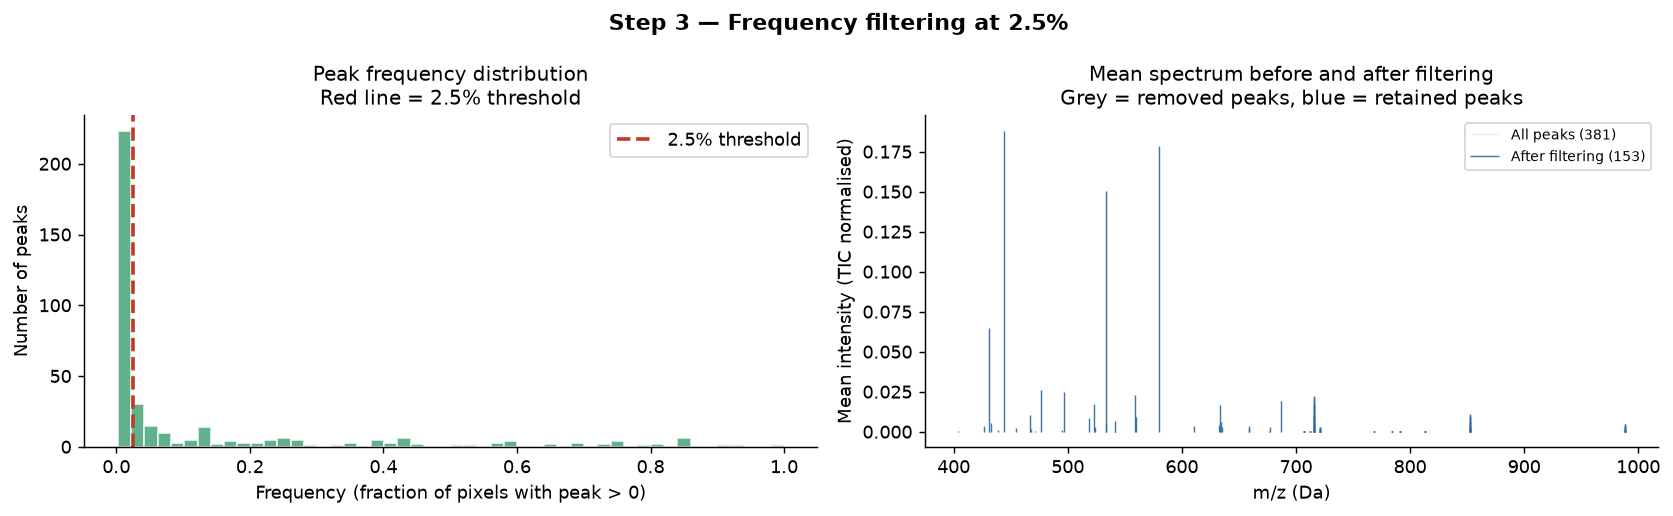

Figure saved.
Peaks removed:  228
Peaks retained: 153


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left — frequency distribution with threshold
axes[0].hist(frequency, bins=50, color="#3a9e6f", alpha=0.8, edgecolor="white")
axes[0].axvline(x=0.025, color="#c0392b", linestyle="--",
                linewidth=2, label="2.5% threshold")
axes[0].set_xlabel("Frequency (fraction of pixels with peak > 0)")
axes[0].set_ylabel("Number of peaks")
axes[0].set_title("Peak frequency distribution\n"
                  "Red line = 2.5% threshold")
axes[0].legend()

# Right — mean spectrum before and after filtering
mean_before_filter = spectra_norm.mean(axis=0)
mean_after_filter  = spectra_pp.mean(axis=0)

axes[1].vlines(bin_mz, ymin=0, ymax=mean_before_filter,
               linewidth=0.4, color="#cccccc", alpha=0.6,
               label=f"All peaks ({len(bin_mz)})")
axes[1].vlines(ref_mz, ymin=0, ymax=mean_after_filter,
               linewidth=0.8, color="#2d6a9f", alpha=0.9,
               label=f"After filtering ({len(ref_mz)})")
axes[1].set_xlabel("m/z (Da)")
axes[1].set_ylabel("Mean intensity (TIC normalised)")
axes[1].set_title("Mean spectrum before and after filtering\n"
                  "Grey = removed peaks, blue = retained peaks")
axes[1].legend(fontsize=8)

fig.suptitle("Step 3 — Frequency filtering at 2.5%",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/01_step3_filtering.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved.")
print(f"Peaks removed:  {len(bin_mz) - len(ref_mz)}")
print(f"Peaks retained: {len(ref_mz)}")

### Final preprocessing result — mean spectrum before vs after

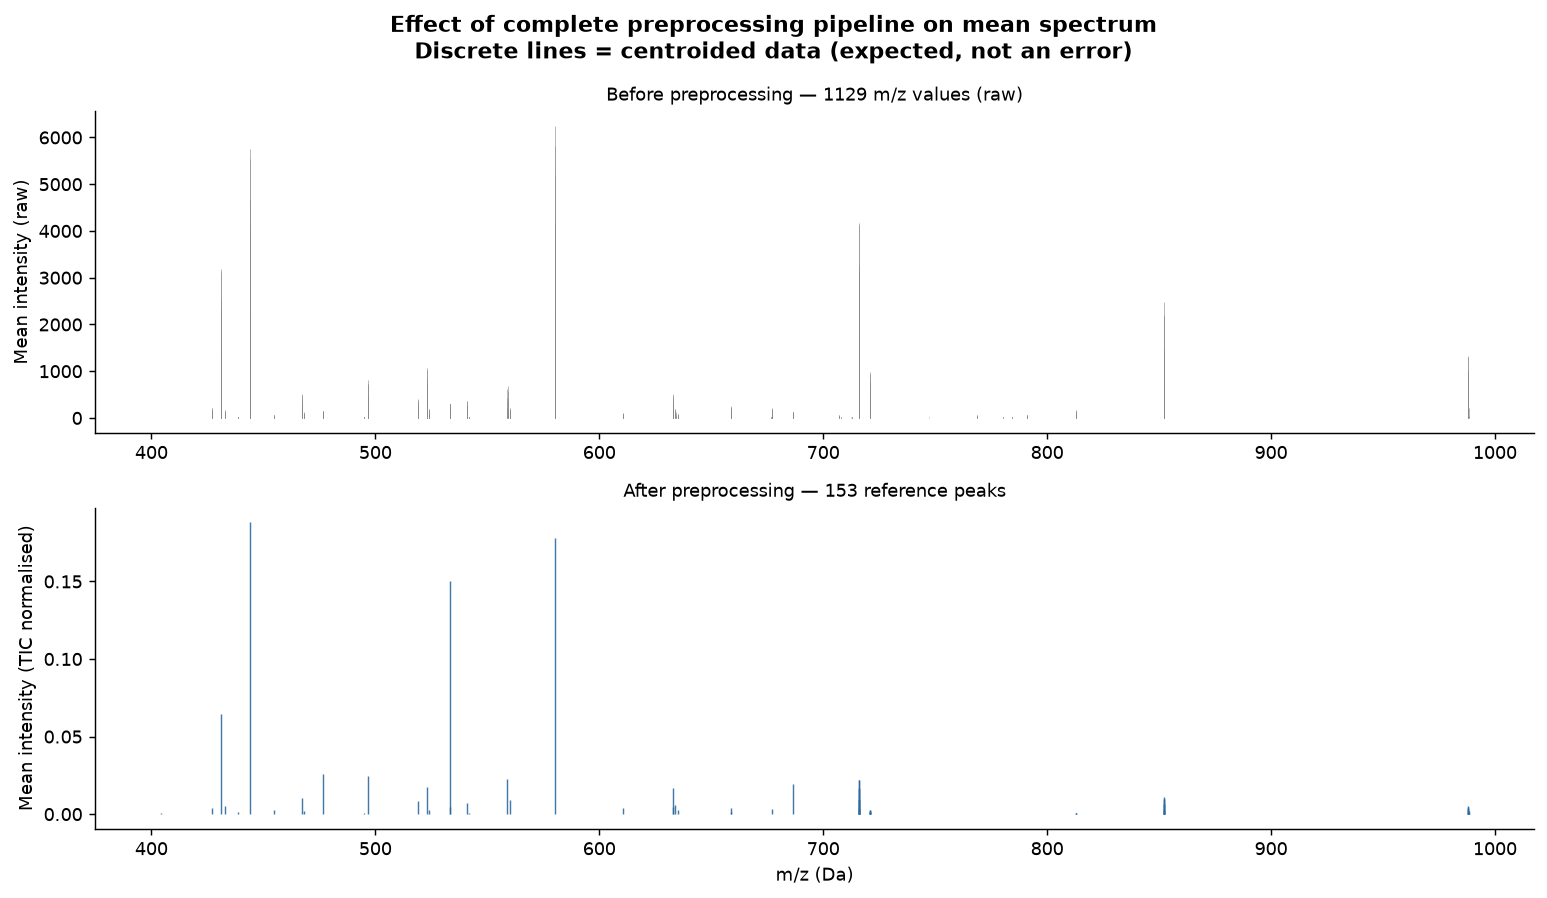

Figure saved.


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].vlines(mz_values, ymin=0, ymax=spectra.mean(axis=0),
               linewidth=0.4, color="#888888", alpha=0.8)
axes[0].set_title(f"Before preprocessing — {spectra.shape[1]} m/z values (raw)",
                  fontsize=10)
axes[0].set_ylabel("Mean intensity (raw)")

axes[1].vlines(ref_mz, ymin=0, ymax=spectra_pp.mean(axis=0),
               linewidth=0.8, color="#2d6a9f", alpha=0.9)
axes[1].set_title(f"After preprocessing — {len(ref_mz)} reference peaks",
                  fontsize=10)
axes[1].set_ylabel("Mean intensity (TIC normalised)")
axes[1].set_xlabel("m/z (Da)")

fig.suptitle("Effect of complete preprocessing pipeline on mean spectrum\n"
             "Discrete lines = centroided data (expected, not an error)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("results/figures/01_preprocessing_effect.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## 6. Most Abundant Peaks — Lipid Class Overview

The most abundant peaks in the preprocessed data correspond to known lipid species.
In the 400–1000 Da range, MALDI-MSI of tissue predominantly detects phospholipids.

**Lipid class assignment based on m/z range:**

| m/z range (Da) | Lipid class |
|---|---|
| 400–460  | Lysophospholipids (LPE, LPI) |
| 460–600  | Lysophosphatidylcholines (LPC) |
| 600–700  | Phosphatidylethanolamines (PE) |
| 700–920  | Phosphatidylcholines (PC) |
| 920–1000 | Triacylglycerols (TAG) / large PC adducts |

> **Important notes:**
> - These are **approximate class assignments** based on m/z range only.
>   Precise lipid identification requires MS/MS fragmentation data.
> - Na⁺ and K⁺ adducts shift these ranges by +22 and +38 Da respectively,
>   so ranges overlap and a single m/z can belong to multiple classes.
> - We report one representative peak **per lipid class** to show molecular
>   diversity — selecting only by abundance would return multiple PCs.
>
> Reference: Hsu & Turk (2009) *J. Chromatogr. B* 877:2714

In [12]:
# Select the most abundant peak per lipid class
# This guarantees the table and ion images show molecular diversity
mean_pp = spectra_pp.mean(axis=0)

seen_classes = {}
for idx in np.argsort(mean_pp)[::-1]:
    cls = assign_lipid_class(ref_mz[idx])
    if cls not in seen_classes:
        seen_classes[cls] = idx
    if len(seen_classes) == 5:
        break

top5_idx = list(seen_classes.values())
top5_mz  = ref_mz[top5_idx]

# Build a frequency lookup: ref_mz maps back into bin_mz via position
# frequency was computed on bin_mz after step 1; ref_mz is the filtered subset
# We stored frequency in preprocessed — it aligns with bin_mz
# ref_mz positions in bin_mz:
ref_freq = preprocessed["frequency"]  # frequency[i] corresponds to bin_mz[i]
# ref_mz is a subset of bin_mz, find matching indices in bin_mz
bin_mz_list = list(bin_mz)

print("Most abundant peak per lipid class after preprocessing:")
print(f"{'Rank':<6} {'m/z (Da)':<12} {'Mean intensity':<18} {'Frequency':<12} {'Lipid class'}")
print("-" * 78)
for rank, (idx, mz) in enumerate(zip(top5_idx, top5_mz), 1):
    lipid = assign_lipid_class(mz)
    # find frequency for this ref peak
    bin_matches = np.where(np.abs(bin_mz - mz) < 1e-6)[0]
    freq_val = ref_freq[bin_matches[0]] if len(bin_matches) > 0 else float("nan")
    print(f"{rank:<6} {mz:<12.4f} {mean_pp[idx]:<18.6f} {freq_val:<12.3f} {lipid}")

Most abundant peak per lipid class after preprocessing:
Rank   m/z (Da)     Mean intensity     Frequency    Lipid class
------------------------------------------------------------------------------
1      444.0893     0.188185           0.924        Lysophospholipid (LPE/LPI)
2      580.1079     0.178218           0.909        Lysophosphatidylcholine (LPC)
3      716.1213     0.022105           0.853        Phosphatidylcholine (PC)
4      686.6087     0.019116           0.641        Phosphatidylethanolamine (PE)
5      988.1502     0.004931           0.585        Triacylglycerol (TAG) / large PC adduct


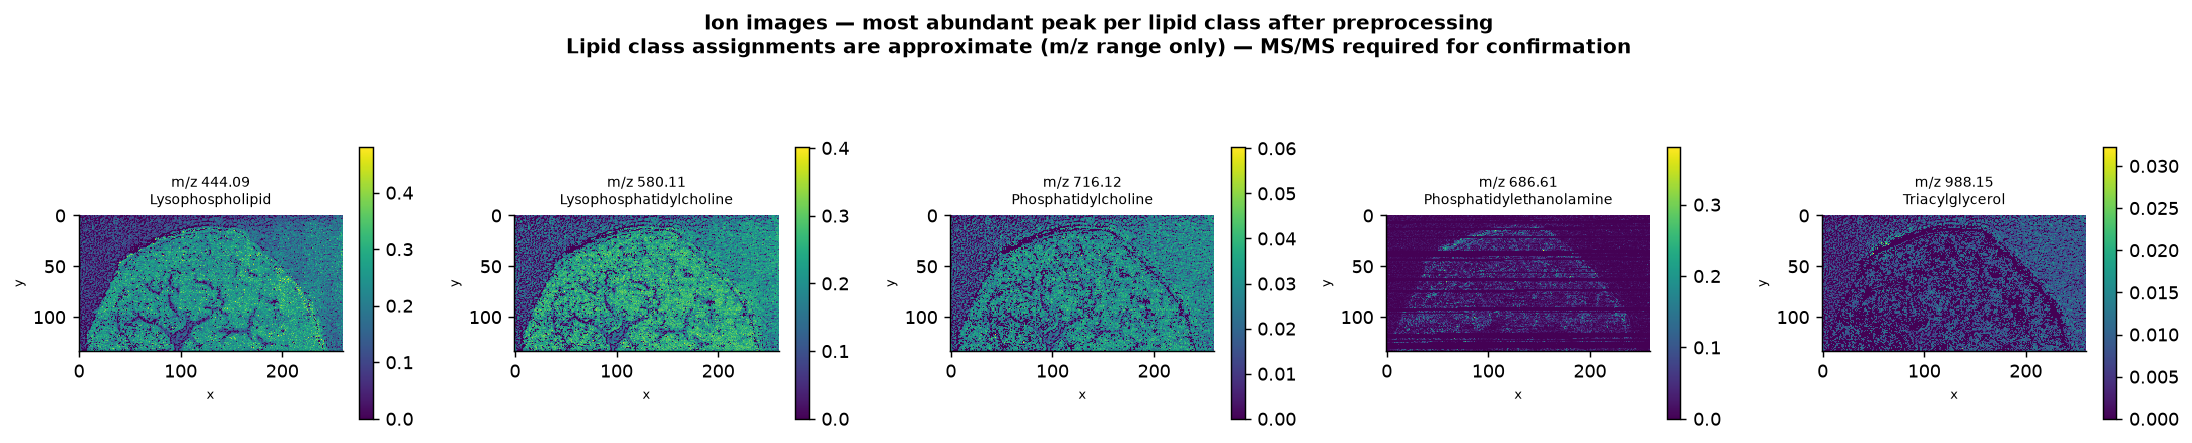

Figure saved.


In [13]:
fig, axes = plt.subplots(1, 5, figsize=(17, 3.8))

for ax, idx, mz in zip(axes, top5_idx, top5_mz):
    ion_map = np.full((y.max()+1, x.max()+1), np.nan)
    ion_map[y, x] = spectra_pp[:, idx]
    im = ax.imshow(ion_map, cmap="viridis",
                   interpolation="nearest", aspect="equal")
    plt.colorbar(im, ax=ax, shrink=0.7)
    lipid = assign_lipid_class(mz).split("(")[0].strip()
    ax.set_title(f"m/z {mz:.2f}\n{lipid}", fontsize=8)
    ax.set_xlabel("x", fontsize=7)
    ax.set_ylabel("y", fontsize=7)

fig.suptitle(
    "Ion images — most abundant peak per lipid class after preprocessing\n"
    "Lipid class assignments are approximate (m/z range only) — MS/MS required for confirmation",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.savefig("results/figures/01_top5_ion_images.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## 7. PCA — Before and After Preprocessing

**PCA (Principal Component Analysis)** reduces each pixel from hundreds of
m/z features to a lower-dimensional space for visualisation and diagnostics.

**How to read PCA:**
- Each point = one pixel
- Points close together = similar molecular profiles
- PC1 (x-axis) = direction of largest variance in the data
- PC2 (y-axis) = second largest variance
- The % in the axis label = how much variance that component explains

**Why no StandardScaler:**  
StandardScaler sets every m/z feature to mean=0, std=1 before PCA.
For MALDI-MSI this is wrong — it gives equal weight to noise peaks
(low intensity, present in 3% of pixels) and dominant lipid signals.
After TIC normalisation, intensities are already comparable across
pixels. We feed `spectra_pp` directly into PCA.

**What we expect:**  
Before preprocessing, PC1 is dominated by raw TIC variation between
pixels — a technical artifact. After preprocessing, variance spreads
more evenly across PCs reflecting biological lipid variation.
Colouring by spatial x-position links PC structure to tissue anatomy:
if tissue layers separate in PCA, spatially adjacent pixels should
cluster together.

Reference: Alexandrov et al. (2010) *J. Proteome Res.* 9:6535

In [14]:
from sklearn.decomposition import PCA

# PCA before preprocessing — raw data, no scaling
# Reflects raw variance: dominated by total signal differences between pixels
pca_b     = PCA(n_components=10, random_state=42)
pc_before = pca_b.fit_transform(spectra)

# PCA after preprocessing — TIC-normalised data, no scaling
# Technical variation removed; biological variance should emerge
pca_a    = PCA(n_components=10, random_state=42)
pc_after = pca_a.fit_transform(spectra_pp)

print(f"PCA before — PC1: {pca_b.explained_variance_ratio_[0]*100:.1f}%  "
      f"PC2: {pca_b.explained_variance_ratio_[1]*100:.1f}%")
print(f"PCA after  — PC1: {pca_a.explained_variance_ratio_[0]*100:.1f}%  "
      f"PC2: {pca_a.explained_variance_ratio_[1]*100:.1f}%")
print(f"\nTotal variance in 10 PCs — before: "
      f"{pca_b.explained_variance_ratio_.sum()*100:.1f}%  "
      f"after: {pca_a.explained_variance_ratio_.sum()*100:.1f}%")

PCA before — PC1: 90.6%  PC2: 5.4%
PCA after  — PC1: 52.7%  PC2: 31.4%

Total variance in 10 PCs — before: 99.4%  after: 98.2%


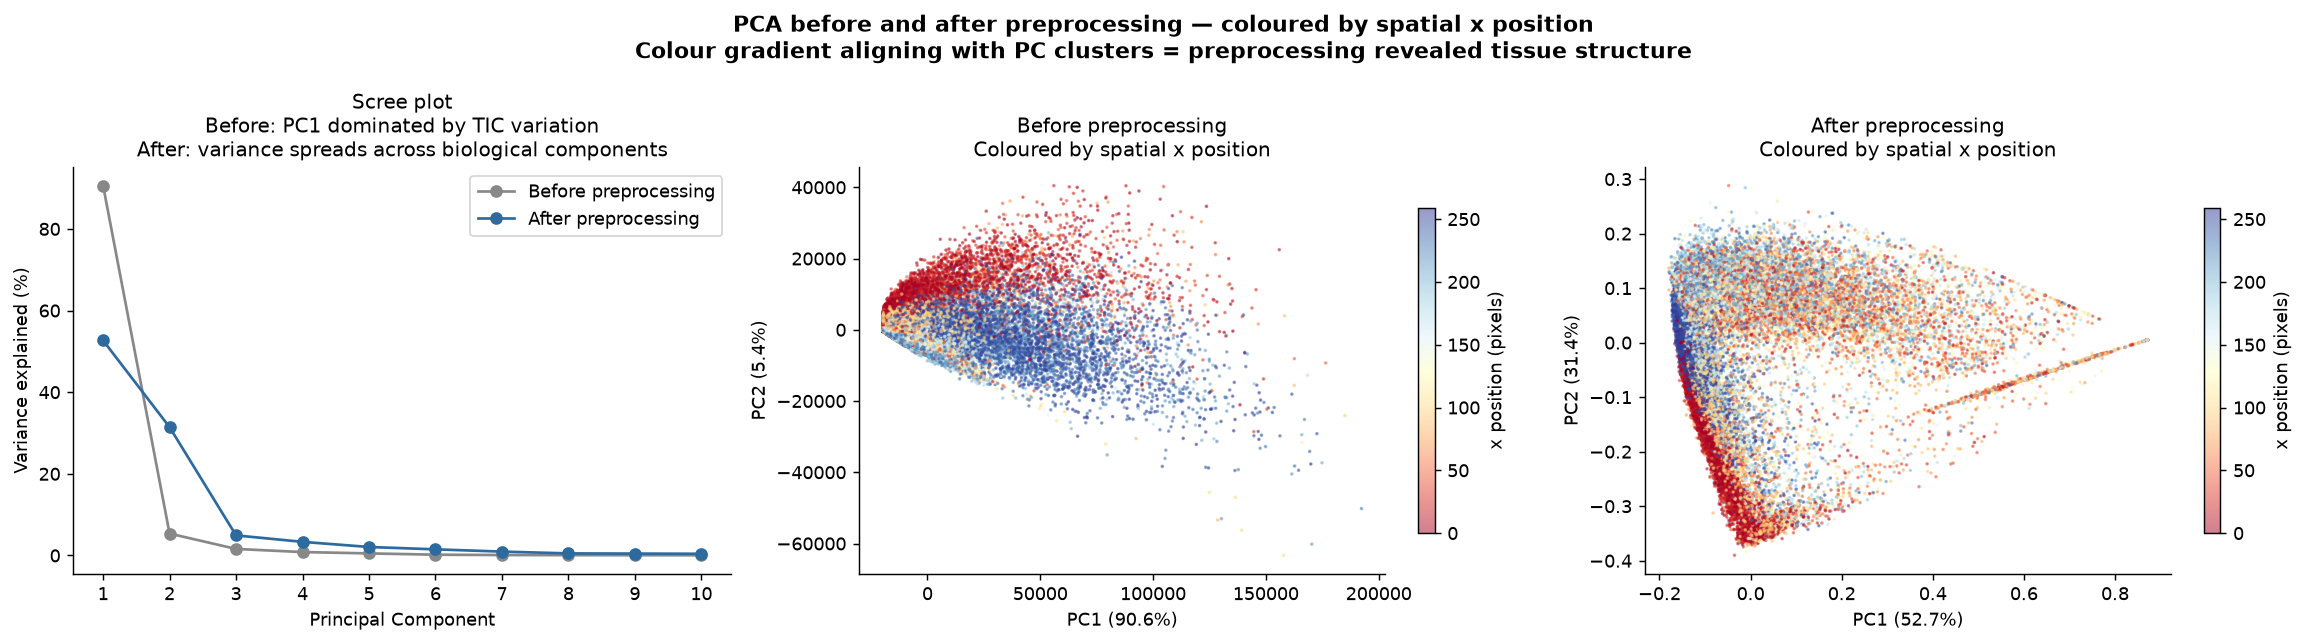

Figure saved.


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1 — Scree plot: variance explained before vs after
n_show = 10
axes[0].plot(range(1, n_show+1),
             pca_b.explained_variance_ratio_[:n_show] * 100,
             "o-", color="#888888", label="Before preprocessing")
axes[0].plot(range(1, n_show+1),
             pca_a.explained_variance_ratio_[:n_show] * 100,
             "o-", color="#2d6a9f", label="After preprocessing")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance explained (%)")
axes[0].set_title("Scree plot\n"
                  "Before: PC1 dominated by TIC variation\n"
                  "After: variance spreads across biological components")
axes[0].legend()
axes[0].set_xticks(range(1, n_show+1))

# Panel 2 — PC1 vs PC2 before, coloured by spatial x position
sc1 = axes[1].scatter(pc_before[:, 0], pc_before[:, 1],
                       c=x, cmap="RdYlBu", s=1, alpha=0.5)
plt.colorbar(sc1, ax=axes[1], label="x position (pixels)", shrink=0.8)
axes[1].set_xlabel(f"PC1 ({pca_b.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca_b.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("Before preprocessing\nColoured by spatial x position")

# Panel 3 — PC1 vs PC2 after, coloured by spatial x position
sc2 = axes[2].scatter(pc_after[:, 0], pc_after[:, 1],
                       c=x, cmap="RdYlBu", s=1, alpha=0.5)
plt.colorbar(sc2, ax=axes[2], label="x position (pixels)", shrink=0.8)
axes[2].set_xlabel(f"PC1 ({pca_a.explained_variance_ratio_[0]*100:.1f}%)")
axes[2].set_ylabel(f"PC2 ({pca_a.explained_variance_ratio_[1]*100:.1f}%)")
axes[2].set_title("After preprocessing\nColoured by spatial x position")

fig.suptitle(
    "PCA before and after preprocessing — coloured by spatial x position\n"
    "Colour gradient aligning with PC clusters = preprocessing revealed tissue structure",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("results/figures/01_pca_before_after.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## 8. t-SNE — Before and After Preprocessing

**t-SNE (t-distributed Stochastic Neighbour Embedding)** is a non-linear
dimensionality reduction method that reveals local cluster structure.

**How to read t-SNE:**
- Each point = one pixel
- Points close together = similar molecular profiles
- Unlike PCA, the axes have **no direct biological meaning** — ticks are removed
- Distinct islands = molecularly distinct tissue regions

**Key difference from PCA:**
- PCA preserves global variance structure
- t-SNE preserves local neighbourhood relationships — better at separating clusters

**Why we show before and after:**  
Same logic as PCA — before preprocessing, the embedding reflects technical
TIC variation between pixels. After preprocessing, tissue structure emerges.
Colouring both by x position makes the comparison direct and honest.

**Why we reduce with PCA first (after preprocessing only):**  
Reducing to 50 PCs removes noise dimensions before t-SNE computes pairwise
distances, making the embedding faster and more accurate.

**Perplexity:**  
Set to `sqrt(n_pixels)`, scaling neighbourhood size to dataset size.

Reference: van der Maaten & Hinton (2008) *J. Mach. Learn. Res.* 9:2579

In [16]:
from sklearn.manifold import TSNE

n_pixels   = spectra_pp.shape[0]
perplexity = min(int(np.sqrt(n_pixels)), 100)

print(f"Pixels: {n_pixels}  |  perplexity = {perplexity}")

# t-SNE before preprocessing — run on raw spectra directly
# (dimensionality is already low enough for this dataset)
print("\nt-SNE before preprocessing...")
tsne_b    = TSNE(n_components=2, random_state=42,
                 perplexity=perplexity, max_iter=1000, verbose=0)
X_tsne_b  = tsne_b.fit_transform(spectra)
print(f"Done. Shape: {X_tsne_b.shape}")

# t-SNE after preprocessing — reduce to 50 PCs first to denoise
print("\nt-SNE after preprocessing (via 50 PCs)...")
pca_50  = PCA(n_components=50, random_state=42)
X_pca50 = pca_50.fit_transform(spectra_pp)
print(f"Variance retained in 50 PCs: {pca_50.explained_variance_ratio_.sum()*100:.1f}%")

tsne_a  = TSNE(n_components=2, random_state=42,
               perplexity=perplexity, max_iter=1000, verbose=0)
X_tsne  = tsne_a.fit_transform(X_pca50)
print(f"Done. Shape: {X_tsne.shape}")

Pixels: 34840  |  perplexity = 100

t-SNE before preprocessing...


Done. Shape: (34840, 2)

t-SNE after preprocessing (via 50 PCs)...
Variance retained in 50 PCs: 100.0%
Done. Shape: (34840, 2)


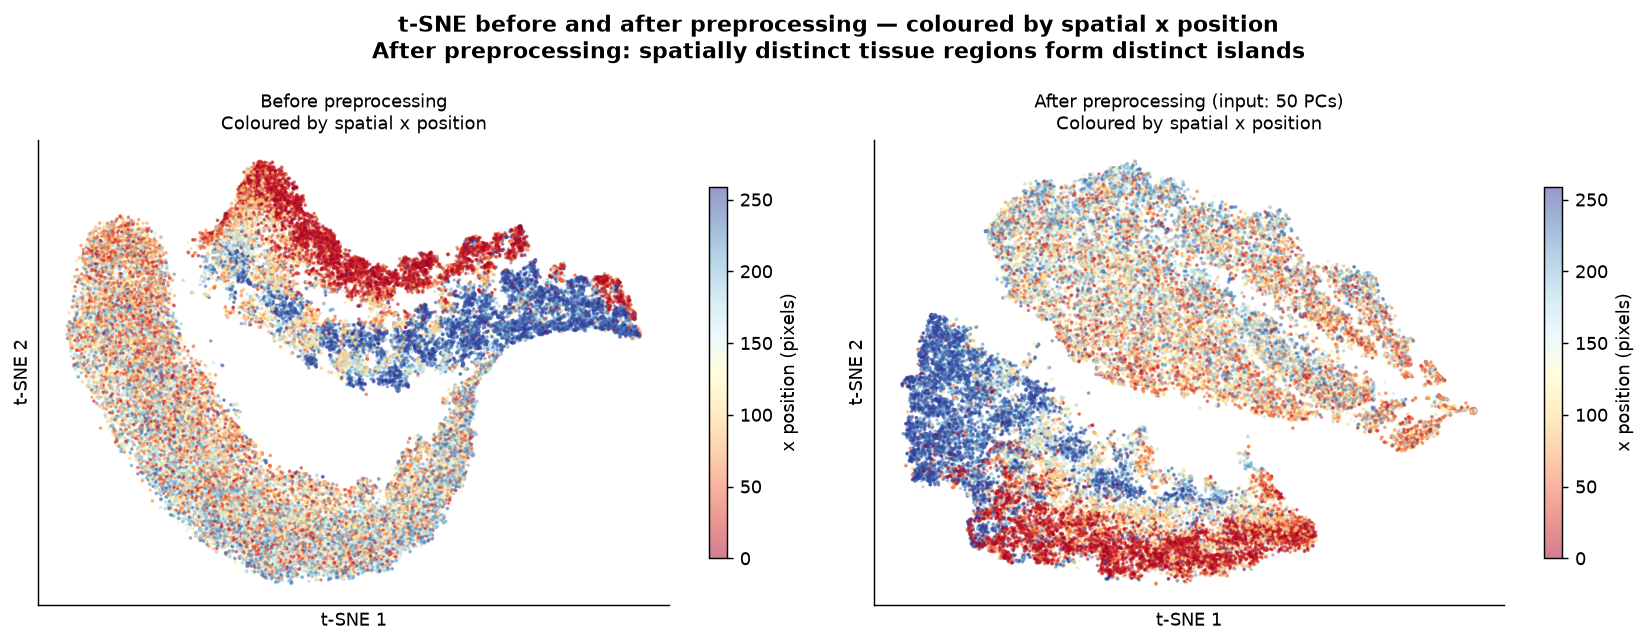

Figure saved.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1 — before preprocessing, coloured by x position
sc0 = axes[0].scatter(X_tsne_b[:, 0], X_tsne_b[:, 1],
                       c=x, cmap="RdYlBu", s=1, alpha=0.5)
plt.colorbar(sc0, ax=axes[0], label="x position (pixels)", shrink=0.8)
axes[0].set_title("Before preprocessing\nColoured by spatial x position", fontsize=10)
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")
axes[0].set_xticks([])
axes[0].set_yticks([])

# Panel 2 — after preprocessing, coloured by x position
sc1 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                       c=x, cmap="RdYlBu", s=1, alpha=0.5)
plt.colorbar(sc1, ax=axes[1], label="x position (pixels)", shrink=0.8)
axes[1].set_title("After preprocessing (input: 50 PCs)\nColoured by spatial x position", fontsize=10)
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].set_xticks([])
axes[1].set_yticks([])

fig.suptitle(
    "t-SNE before and after preprocessing — coloured by spatial x position\n"
    "After preprocessing: spatially distinct tissue regions form distinct islands",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("results/figures/01_tsne.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

> **Note:** Some x-position gradient remains within clusters after preprocessing.
> This is biologically expected — bladder tissue layers run roughly parallel to
> the x-axis, so spatial position and molecular identity are genuinely correlated.
> It is not a sign of residual technical artifact.

## 9. Save Preprocessed Data

In [18]:
np.save("results/spectra_preprocessed.npy", spectra_pp)
np.save("results/spectra_norm.npy",         spectra_norm)
np.save("results/reference_mz.npy",         ref_mz)
np.save("results/mz_values.npy",            mz_values)
np.save("results/pca_embedding.npy",        pc_after)
np.save("results/tsne_embedding.npy",       X_tsne)
coordinates.to_csv("results/coordinates.csv", index=False)

print("Saved:")
print("  results/spectra_preprocessed.npy")
print("  results/spectra_norm.npy")
print("  results/reference_mz.npy")
print("  results/pca_embedding.npy")
print("  results/tsne_embedding.npy")
print("  results/coordinates.csv")
print(f"\nFinal feature matrix: {spectra_pp.shape[0]} pixels x {spectra_pp.shape[1]} peaks")

Saved:
  results/spectra_preprocessed.npy
  results/spectra_norm.npy
  results/reference_mz.npy
  results/pca_embedding.npy
  results/tsne_embedding.npy
  results/coordinates.csv

Final feature matrix: 34840 pixels x 153 peaks


## Summary

| Step | What | Result |
|---|---|---|
| Load | imzML, 400–1000 Da | Raw centroided matrix |
| TIC map | Sum per pixel | Tissue shape visible |
| Mean spectrum | Average across pixels | Overall peak profile |
| Pixel comparison | Centre vs periphery | Motivates need for preprocessing |
| Step 1 — rebin 10 ppm | Align m/z across pixels | Common m/z axis |
| Step 2 — TIC norm | Divide by total signal | Comparable intensities (TIC CV → 0) |
| Step 3 — filter 2.5% | Remove rare peaks | Reference peak list |
| Step 4 — rebin to ref | Integrate to references | Final feature matrix |
| Top peaks | Most abundant per lipid class | Molecular diversity across classes |
| PCA | Scree + scatter, x-coloured | Preprocessing reduced technical noise |
| t-SNE | Before vs after, x-coloured | Tissue regions form distinct islands |

**Next:** Notebook 02 — Segmentation